In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [12]:
BASE_DIR = Path("/content/drive/MyDrive/mbti-tune")
DATA_DIR = BASE_DIR / "data/processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
from google.colab import drive
import os

# Attempt to unmount first to ensure a clean state
try:
    drive.flush_and_unmount()
except ValueError:
    pass # Drive was not mounted, so nothing to unmount

# Ensure the mount point is empty before mounting
mountpoint = '/content/drive'
if os.path.exists(mountpoint) and os.path.isdir(mountpoint):
    if os.listdir(mountpoint):
        print(f"Clearing contents of {mountpoint} before mounting.")
        for item in os.listdir(mountpoint):
            item_path = os.path.join(mountpoint, item)
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                import shutil
                shutil.rmtree(item_path)

drive.mount(mountpoint, force_remount=True)

Mounted at /content/drive


In [10]:
spotify = pd.read_csv(DATA_DIR / "spotify_clean.csv")

print("Shape:", spotify.shape)
display(spotify.head())
print(spotify.dtypes)

Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [14]:
numeric_df = spotify.select_dtypes(include=np.number).copy()

print("Numeric shape:", numeric_df.shape)

Numeric shape: (114000, 14)


In [15]:
scaler = StandardScaler()
X = scaler.fit_transform(numeric_df)
input_dim = X.shape[1]

print("Input dim:", input_dim)

Input dim: 14


In [16]:
def build_autoencoder(input_dim, latent_dim):
    # Encoder
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dense(64, activation="relu")(x)
    z = layers.Dense(latent_dim, name="latent")(x)

    # Decoder
    x = layers.Dense(64, activation="relu")(z)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)

    autoencoder = keras.Model(inputs, outputs)
    encoder = keras.Model(inputs, z)

    autoencoder.compile(optimizer="adam", loss="mse")

    return autoencoder, encoder

In [17]:
latent_dims = [2, 4, 6, 8]

histories = {}
models = {}
encoders = {}
results = []

In [18]:
for dim in latent_dims:
    print(f"\nTraining latent_dim={dim}")

    autoencoder, encoder = build_autoencoder(input_dim, dim)

    history = autoencoder.fit(
        X, X,
        epochs=30,
        batch_size=256,
        validation_split=0.1,
        verbose=0
    )

    # predictions
    X_pred = autoencoder.predict(X, verbose=0)

    mse = np.mean((X - X_pred) ** 2)

    histories[dim] = history
    models[dim] = autoencoder
    encoders[dim] = encoder

    # save model
    model_path = MODEL_DIR / f"autoencoder_dim_{dim}.keras"
    encoder_path = MODEL_DIR / f"encoder_dim_{dim}.keras"

    autoencoder.save(model_path)
    encoder.save(encoder_path)

    results.append({
        "latent_dim": dim,
        "mse": mse
    })

    print(f"latent_dim={dim} | MSE={mse:.6f}")


Training latent_dim=2
latent_dim=2 | MSE=0.336345

Training latent_dim=4
latent_dim=4 | MSE=0.157010

Training latent_dim=6
latent_dim=6 | MSE=0.070411

Training latent_dim=8
latent_dim=8 | MSE=0.026984


In [19]:
results_df = pd.DataFrame(results).sort_values("latent_dim")

display(results_df)

,latent_dim,mse
0,2,0.336345
1,4,0.157010
2,6,0.070411
3,8,0.026984


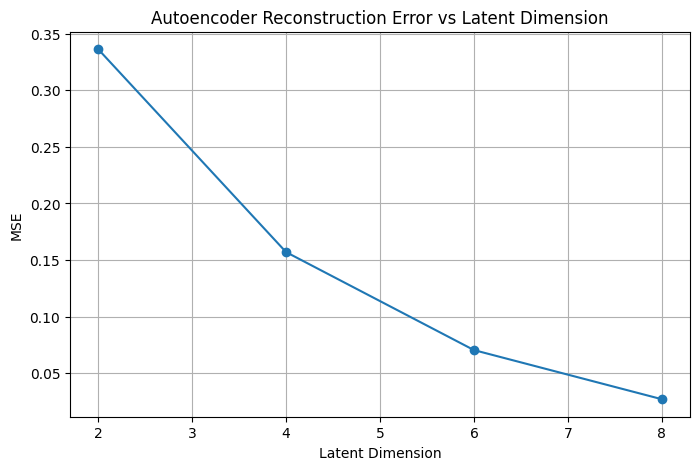

In [20]:
plt.figure(figsize=(8,5))
plt.plot(results_df["latent_dim"], results_df["mse"], marker="o")
plt.title("Autoencoder Reconstruction Error vs Latent Dimension")
plt.xlabel("Latent Dimension")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

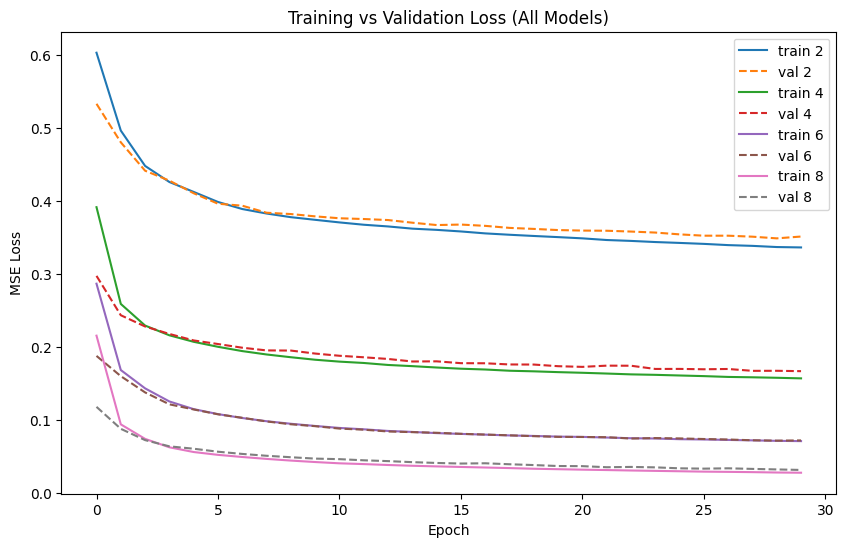

In [21]:
plt.figure(figsize=(10,6))

for dim in latent_dims:
    plt.plot(histories[dim].history["loss"], label=f"train {dim}")
    plt.plot(histories[dim].history["val_loss"], linestyle="--", label=f"val {dim}")

plt.title("Training vs Validation Loss (All Models)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

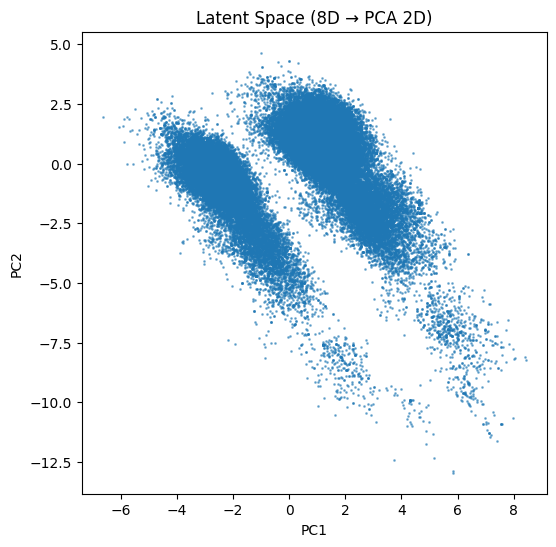

In [22]:
from sklearn.decomposition import PCA

encoder_8 = encoders[8]
Z = encoder_8.predict(X, verbose=0)

pca = PCA(n_components=2)
Z2 = pca.fit_transform(Z)

plt.figure(figsize=(6,6))
plt.scatter(Z2[:,0], Z2[:,1], s=1, alpha=0.5)
plt.title("Latent Space (8D → PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [23]:
print("=== FINAL SUMMARY ===")
print(results_df)

best = results_df.loc[results_df["mse"].idxmin()]
print("\nBest model:")
print(best)

=== FINAL SUMMARY ===
   latent_dim       mse
0           2  0.336345
1           4  0.157010
2           6  0.070411
3           8  0.026984

Best model:
latent_dim    8.000000
mse           0.026984
Name: 3, dtype: float64
